# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Kamalanand Sangameswaran

**Date:** Sep 2 2026

In [1]:
# imports
import pandas as pd

In [34]:
# Your Phase 1 solution to the problem goes here.
df = pd.read_csv("./data/airbnb_hw.csv")

In [5]:
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [6]:
df.tail()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
30473,43022976,8/31/2015,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN
30474,42993382,8/31/2015,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN
30475,43033067,8/31/2015,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN
30476,43000991,8/31/2015,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN
30477,42999189,8/31/2015,Huge Beautiful Bedroom - Astoria,Queens,House,NaN,Private room,11105.0,1.0,1,0,80,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  object 
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(3), object

In [12]:
df.head()
df.info()
df["Price"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  object 
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(3), object

array(['145', '37', '28', '199', '549', '149', '250', '90', '270', '290',
       '170', '59', '49', '68', '285', '75', '100', '150', '700', '125',
       '175', '40', '89', '95', '99', '499', '120', '79', '110', '180',
       '143', '230', '350', '135', '85', '60', '70', '55', '44', '200',
       '165', '115', '74', '84', '129', '50', '185', '80', '190', '140',
       '45', '65', '225', '600', '109', '1,990', '73', '240', '72', '105',
       '155', '160', '42', '132', '117', '295', '280', '159', '107', '69',
       '239', '220', '399', '130', '375', '585', '275', '139', '260',
       '35', '133', '300', '289', '179', '98', '195', '29', '27', '39',
       '249', '192', '142', '169', '1,000', '131', '138', '113', '122',
       '329', '101', '475', '238', '272', '308', '126', '235', '315',
       '248', '128', '56', '207', '450', '215', '210', '385', '445',
       '136', '247', '118', '77', '76', '92', '198', '205', '299', '222',
       '245', '104', '153', '349', '114', '320', '292', '22

In [35]:
df["Price"] = df["Price"].astype(str).str.replace(",", "")
df["Price"] = pd.to_numeric(df["Price"])

In [26]:
df["Price"].dtype

dtype('int64')

In [27]:
df["Price"].isna().sum()

np.int64(0)

In [37]:
df["Price"].describe()
df["Price"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30478 entries, 0 to 30477
Series name: Price
Non-Null Count  Dtype
--------------  -----
30478 non-null  int64
dtypes: int64(1)
memory usage: 238.2 KB


Q1 part 1:  When I did the info command, I saw price was an object datatype instead of numeric, probably cause it had commas after 1,000.
I removed the commas and converted the variable to numeric using pd.to_numeric(). After cleaning, the variable was stored as an integer (int64) and had 0 missing values.

In [29]:
df2 = pd.read_csv("./data/mn_police_use_of_force.csv")

In [31]:
df2["subject_injury"].unique()

array([nan, 'No', 'Yes'], dtype=object)

In [32]:
df2["subject_injury"].value_counts(dropna=False)

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

In [39]:
df2["subject_injury"].isna().mean()

np.float64(0.7619342359767892)

In [40]:
pd.crosstab(
    df2["force_type"],
    df2["subject_injury"],
    dropna=False
)

subject_injury,No,Yes,NaN
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


In [42]:
df2["subject_injury_clean"] = df2["subject_injury"].fillna("No")
df2["subject_injury_clean"].value_counts()

subject_injury_clean
No     11294
Yes     1631
Name: count, dtype: int64

In [43]:
pd.crosstab(
    df2["force_type"],
    df2["subject_injury_clean"]
)

subject_injury_clean,No,Yes
force_type,,
Baton,2,2
Bodily Force,8144,1286
Chemical Irritant,1552,41
Firearm,2,0
Gun Point Display,60,44
Improvised Weapon,108,40
Less Lethal,87,0
Less Lethal Projectile,1,2
Maximal Restraint Technique,170,0


Q1 Part 2: I cleaned subject_injury by replacing the missing values with No. There were 9848 missing values out of 12925 observations, meaning about 76.2% of the values were missing. This is a pretty big concern cause such a large amount of the data was missing. The missing values also seem to be related to force_type, and not just showing randomly. For example, it has Bodily Force, Chemical Irritant, and Taser account for most of the missing values, while some force types have few or no missing values. Some force types, such as Firearm and Less Lethal Projectile, have no missing values. This suggests that missingness is associated with the type of force used.

In [56]:
df3 = pd.read_excel("./data/GSAF5.xls")

In [57]:
df3.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7117 entries, 0 to 7116
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7117 non-null   object 
 1   Year            7115 non-null   float64
 2   Type            7099 non-null   object 
 3   Country         7067 non-null   object 
 4   State           6630 non-null   object 
 5   Location        6550 non-null   object 
 6   Activity        6534 non-null   object 
 7   Name            6899 non-null   object 
 8   Sex             6539 non-null   object 
 9   Age             4123 non-null   object 
 10  Injury          7081 non-null   object 
 11  Fatal Y/N       6556 non-null   object 
 12  Time            3590 non-null   object 
 13  Species         3986 non-null   object 
 14  Source          7097 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

In [59]:
df3.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')

In [60]:
df3[["Unnamed: 21", "Unnamed: 22"]].value_counts(dropna=False)

Unnamed: 21   Unnamed: 22    
NaN           NaN                7114
stopped here  NaN                   1
NaN           Teramo                1
              change filename       1
Name: count, dtype: int64

In [61]:
df3 = df3.drop(columns=["Unnamed: 21", "Unnamed: 22"])
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7117 entries, 0 to 7116
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7117 non-null   object 
 1   Year            7115 non-null   float64
 2   Type            7099 non-null   object 
 3   Country         7067 non-null   object 
 4   State           6630 non-null   object 
 5   Location        6550 non-null   object 
 6   Activity        6534 non-null   object 
 7   Name            6899 non-null   object 
 8   Sex             6539 non-null   object 
 9   Age             4123 non-null   object 
 10  Injury          7081 non-null   object 
 11  Fatal Y/N       6556 non-null   object 
 12  Time            3590 non-null   object 
 13  Species         3986 non-null   object 
 14  Source          7097 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

In [62]:
df3["Year"].unique()
df3["Year"].describe()

count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64

In [63]:
df3["Year"] = df3["Year"].replace(0, pd.NA)
df3["Year"].describe()

In [64]:
df3_since_1940 = df3[df3["Year"] >= 1940]
df3_since_1940["Year"].describe()
df3_since_1940["Year"].value_counts().sort_index()

Year
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: count, Length: 87, dtype: int64

After filtering the data to attacks since 1940, the number of reported shark attacks generally increased over time. Although there are fluctuations between individual years, the overall number of attacks is higher in recent decades than in the 1940s.

In [65]:
df3["Age"].unique()

array(['?', '43', '27', '71', '21', '69', '31', '13', '12', '17', '35',
       "20's", '19', '11', '20', '38', '39', '16', '22', '30+', "50's",
       '55', '26', '56', '24', '25', '61', '40', '14', '50+', '54', '48',
       '57', '8', '63', '9', '7', '85', '18', '66', '37', '42', '45',
       '30', '60', '40+', '29', 35, 58, 29, 24, 20, 55, 17, 12, 37, 36,
       23, 40, 28, 69, 48, '60+', 57, 45, 61, 27, 38, 16, 68, 33, 30, 15,
       41, 14, 43, 26, 'Middle age', 18, 21, 49, 25, 46, 19, 65, 64, nan,
       '46', '32', '10', '64', '62', '15', '52', '44', '47', '59', '50',
       '34', '30s', '20/30', '65', '20s', '77', '49', '!2', '73', '50s',
       '58', '67', '6', '41', '53', '68', '51', 39, 51, 10, 13, 60, '40s',
       62, 'teen', 8, 22, 32, 56, 'Teen', 42, 50, 'M', 9, 31, 11, 34,
       '!6', '!!', 47, 7, 71, 59, 53, 54, 75, '45 and 15', 73, 52, 70, 4,
       63, 44, '28 & 22', '22, 57, 31', '60s', 67, 74, '9 & 60',
       'a minor', 6, 3, 82, '40?', 66, 72, '23', '36', '70', '

In [67]:
df3["Age_clean"] = pd.to_numeric(df3["Age"], errors="coerce")
df3["Age_clean"].describe()

count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64

In [68]:
df3["Age_clean"].isna().sum()


np.int64(3169)

<Axes: >

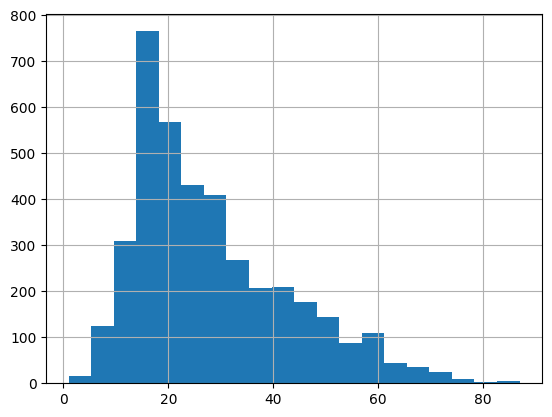

In [69]:
df3["Age_clean"].hist(bins=20)

I converted the Age variable to number values and changed non-number or ambiguous entries to missing values. This resulted in 3948 usable ages ranging from 1 to 87. Although some potentially useful ages were removed, this avoids making unsupported assumptions about unclear values.
The distribution is right-skewed, with most victims concentrated in their teens and twenties and fewer victims at older ages.

In [70]:
df3["Sex"].value_counts(dropna=False)

Sex
M        5704
F         816
NaN       578
M           7
?           2
F           2
N           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64

In [72]:
df3["Sex_clean"] = df3["Sex"].str.strip().str.upper()
male_proportion = (df3["Sex_clean"] == "M").sum() / df3["Sex_clean"].notna().sum()
male_proportion

np.float64(0.8736809909772136)

87.4% of victims with a reported sex were male

In [73]:
df3["Type"].value_counts(dropna=False)

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
NaN                      18
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64

In [74]:
df3["Type_clean"] = df3["Type"].str.strip().str.title()

In [75]:
df3["Type_clean"] = df3["Type_clean"].where(
    df3["Type_clean"].isin(["Provoked", "Unprovoked"]),
    "Unknown"
)

In [76]:
df3["Type_clean"].value_counts()

Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64

I standardized capitalization and whitespace and kept Provoked and Unprovoked and classified all other values as Unknown

In [77]:
unprovoked_proportion = (df3["Type_clean"] == "Unprovoked").mean()
unprovoked_proportion

np.float64(0.7394969790642124)

74% of the attacks were classified as unprovoked

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]